# Beirut street-view - full analysis

Everything the project does lives in this notebook. Run the cells top to bottom.

**Pipeline**

0. Fetch image metadata from Mapillary (≈44k rows → `beirut_metadata.csv.gz`)
1. Download the actual JPEGs (resume-safe; skip if already on disk)
2. Compute CLIP embeddings for every image (resume-safe; saves every batch; **panos are cubemap-unwrapped** into 4 perspective views before scoring)
2b. **Semantic segmentation** (SegFormer-Cityscapes) - per-image `vegetation_frac`, `sky_frac`, `road_frac`, `building_frac`, `terrain_frac`
3. **Suspicious / damaged buildings** - classifier trained on CLIP features with sequence-aware 5-fold CV, weak labels from the Aug 4 2020 port explosion
3b. **Metadata-only baseline (Approach B)** - Random Forest on lat/lon/altitude/date/sequence-stats. Sanity check: is the vision model actually adding signal?
3c. **A vs B decision** - Pearson r + top-K overlap → verdict text in `outputs/decision.txt`
4. **3D model of the city** - interactive 3D scene of every camera pose
5. **Closest places to a given picture** - CLIP + FAISS visual-similarity search
6. **Greenery analysis** - city-wide green cover map, change over time, port-radius greenness pre- vs post-2020-08-04
7. **3D dataset browser** - one self-contained HTML with map + 3D scene + search + gallery + CSV export

Every figure auto-saves to `outputs/fig_NN.png`. Every derived table saves to `outputs/*.csv`.

**Prerequisites:** `pip install requests pandas numpy pillow matplotlib torch open_clip_torch faiss-cpu plotly scikit-learn scipy transformers huggingface_hub tqdm`

In [ ]:
import getpass, math, os, subprocess, sys, time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

# Windows + conda fix: avoid the "libiomp5md.dll already initialized" crash
# when torch and faiss both pull in OpenMP runtimes. Must be set BEFORE any
# torch / faiss import anywhere in the notebook.
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from PIL import Image

# =============================================================================
#  Persistence - so images, embeddings, and model weights survive a runtime reset
# =============================================================================
# * Local machine  -> everything lives next to the notebook (already persistent)
# * Colab / Kaggle -> mount Google Drive and put everything under
#                     `MyDrive/beirut_project/` so no re-download is ever needed
# * Override anywhere with env var  BEIRUT_BASE_DIR=/some/path
# -----------------------------------------------------------------------------
IN_COLAB = 'google.colab' in sys.modules

_env_base = os.environ.get('BEIRUT_BASE_DIR', '').strip()
if _env_base:
    PERSIST_BASE = Path(_env_base).resolve()
    print(f'Persistence : env override -> {PERSIST_BASE}')
elif IN_COLAB:
    # Try to mount Drive so nothing gets wiped on runtime restart
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        PERSIST_BASE = Path('/content/drive/MyDrive/beirut_project')
        PERSIST_BASE.mkdir(parents=True, exist_ok=True)
        print(f'Persistence : Google Drive -> {PERSIST_BASE}')
        print('              (first session downloads ~15 GB to Drive; later sessions skip it entirely)')
    except Exception as e:
        PERSIST_BASE = Path('/content').resolve()
        print(f'Persistence : /content/ (Drive mount failed: {e}) - runtime restart WILL wipe images')
else:
    PERSIST_BASE = Path.cwd().resolve()
    print(f'Persistence : local dir -> {PERSIST_BASE}')

# --- where things live ---
IMG_DIR     = Path(os.environ.get('IMG_DIR_OVERRIDE', PERSIST_BASE / 'images_2048')).resolve()
OUTPUTS_DIR = PERSIST_BASE / 'outputs'
META_PATH   = PERSIST_BASE / 'beirut_metadata.csv.gz'
EMB_PATH    = PERSIST_BASE / 'embeddings.npy'
IDS_PATH    = PERSIST_BASE / 'embeddings_ids.txt'
SEG_CACHE   = PERSIST_BASE / 'segmentation_scores.csv'
IMG_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# Route HuggingFace + torch model caches into PERSIST_BASE too, so the ~300 MB
# CLIP checkpoint and ~14 MB SegFormer checkpoint download only ONCE ever.
os.environ['HF_HOME']              = str(PERSIST_BASE / 'hf_cache')
os.environ['HUGGINGFACE_HUB_CACHE'] = str(PERSIST_BASE / 'hf_cache' / 'hub')
os.environ['TRANSFORMERS_CACHE']   = str(PERSIST_BASE / 'hf_cache' / 'transformers')
os.environ['TORCH_HOME']           = str(PERSIST_BASE / 'torch_cache')
(PERSIST_BASE / 'hf_cache').mkdir(parents=True, exist_ok=True)
(PERSIST_BASE / 'torch_cache').mkdir(parents=True, exist_ok=True)

# Quick status: what's already cached from previous runs?
n_jpgs = sum(1 for _ in IMG_DIR.glob('*.jpg'))
print(f'\nIMG_DIR     = {IMG_DIR}   ({n_jpgs:,} JPEGs already on disk)')
print(f'OUTPUTS_DIR = {OUTPUTS_DIR}')
def _status(path, action):
    return 'exists' if path.exists() else f'MISSING (Step {action} will build)'
print(f'metadata     = {_status(META_PATH,  "0")}    {META_PATH}')
print(f'embeddings   = {_status(EMB_PATH,   "2")}    {EMB_PATH}')
print(f'segmentation = {_status(SEG_CACHE,  "2b")}   {SEG_CACHE}')

# --- landmark constants (used across many cells) ---
PORT_LAT, PORT_LON = 33.9020, 35.5180                 # Beirut port explosion epicenter
EXPLOSION          = pd.Timestamp('2020-08-04')
PORT_RADIUS_DEG    = 0.010                            # ~1.1 km

# --- auto-save every matplotlib figure to OUTPUTS_DIR ---
# So a runtime disconnect doesn't cost you the plots.  fig_01.png, fig_02.png, ...
_orig_show   = plt.show
_fig_counter = [0]
def _autosave_show(*args, **kwargs):
    _fig_counter[0] += 1
    path = OUTPUTS_DIR / f'fig_{_fig_counter[0]:02d}.png'
    try:
        plt.gcf().savefig(path, dpi=140, bbox_inches='tight')
        print(f'  [saved] {path.name}')
    except Exception as e:
        print(f'  [autosave skipped] {e}')
    return _orig_show(*args, **kwargs)
plt.show = _autosave_show

# --- HuggingFace token (mandatory, hidden input) ---
# SegFormer + open_clip weights come from HF. Anonymous downloads get
# rate-limited, which is what silently cost 3 h last run. A token also
# unlocks any gated model you might swap in later.
# Cached in this kernel session and mirrored into $HF_TOKEN so every
# `from_pretrained(...)` call downstream authenticates automatically.
HF_TOKEN = os.environ.get('HF_TOKEN') or os.environ.get('HUGGINGFACE_HUB_TOKEN')
if not HF_TOKEN:
    HF_TOKEN = getpass.getpass('HuggingFace token (hf_...): ').strip()
assert HF_TOKEN.startswith('hf_'), 'expected token starting with hf_'
os.environ['HF_TOKEN']              = HF_TOKEN
os.environ['HUGGINGFACE_HUB_TOKEN'] = HF_TOKEN
try:
    from huggingface_hub import login as _hf_login
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'huggingface_hub'])
    from huggingface_hub import login as _hf_login
_hf_login(token=HF_TOKEN, add_to_git_credential=False)
print('HF token: ok')

# --- Mapillary token (hidden input - never typed in plaintext, never logged) ---
# Cached in this kernel session: re-running this cell reuses the token.
MAPILLARY_TOKEN = os.environ.get('MAPILLARY_TOKEN')
if not MAPILLARY_TOKEN:
    MAPILLARY_TOKEN = getpass.getpass('Mapillary token (MLY|...): ').strip()
    os.environ['MAPILLARY_TOKEN'] = MAPILLARY_TOKEN
assert MAPILLARY_TOKEN.startswith('MLY|'), 'expected token starting with MLY|'
print('token: ok')

## Step 0 - Fetch image metadata from Mapillary

Pulls only the fields the rest of the notebook needs:
`id, sequence, captured_at, lon, lat, compass_angle, altitude, is_pano, thumb_2048_url`.
Splits the bbox recursively where a cell hits the 2000-result cap. Output:
`beirut_metadata.csv.gz` (re-runnable; overwrites).

In [2]:
# Skip re-fetching if we already have a CSV AND embeddings - fetching again
# would create ID drift vs. the embeddings (Mapillary changes between fetches).
# To force a fresh fetch, delete embeddings.npy (or beirut_metadata.csv.gz) first.
if META_PATH.exists() and EMB_PATH.exists():
    print(f'[cached] metadata + embeddings both present -> skipping Mapillary fetch.')
    print(f'         {META_PATH}')
    df = pd.read_csv(META_PATH)
    df['id'] = df['id'].astype(str)
    df['captured_at_dt'] = pd.to_datetime(df['captured_at'], unit='ms')
    print(f'  {len(df):,} rows   {META_PATH.stat().st_size/1e6:.1f} MB')
else:
    # Beirut bbox: coast to downtown, port, Hamra, Achrafieh, southern suburbs
    WEST, SOUTH, EAST, NORTH = 35.470, 33.860, 35.570, 33.920
    INITIAL_COLS, INITIAL_ROWS = 10, 6
    MAX_DEPTH = 5

    # Minimal field list - only what later cells need
    FIELDS = ','.join([
        'id', 'sequence', 'captured_at', 'geometry',
        'compass_angle', 'computed_compass_angle',
        'altitude', 'computed_altitude',
        'is_pano', 'thumb_2048_url',
    ])

    def fetch_cell(w, s, e, n, retries=5):
        url = 'https://graph.mapillary.com/images'
        params = {'access_token': MAPILLARY_TOKEN, 'bbox': f'{w},{s},{e},{n}', 'fields': FIELDS, 'limit': 2000}
        for attempt in range(retries):
            try:
                r = requests.get(url, params=params, timeout=90)
                r.raise_for_status()
                return r.json().get('data', [])
            except Exception:
                if attempt == retries - 1: return []
                time.sleep(min(2 ** attempt, 15))
        return []

    def fetch_recursive(w, s, e, n, depth=0):
        data = fetch_cell(w, s, e, n)
        if len(data) < 2000 or depth >= MAX_DEPTH:
            return data
        mid_w, mid_s = (w + e) / 2, (s + n) / 2
        subs = [(w, s, mid_w, mid_s), (mid_w, s, e, mid_s), (w, mid_s, mid_w, n), (mid_w, mid_s, e, n)]
        out = []
        with ThreadPoolExecutor(max_workers=4) as ex:
            for f in as_completed([ex.submit(fetch_recursive, *sub, depth + 1) for sub in subs]):
                out.extend(f.result())
        return out

    def flatten(img):
        coords = (img.get('geometry') or {}).get('coordinates') or [None, None]
        return {
            'id': img.get('id'),
            'sequence': img.get('sequence'),
            'captured_at': img.get('captured_at'),
            'lon': coords[0], 'lat': coords[1],
            'compass_angle': img.get('compass_angle'),
            'computed_compass_angle': img.get('computed_compass_angle'),
            'altitude': img.get('altitude'),
            'computed_altitude': img.get('computed_altitude'),
            'is_pano': img.get('is_pano'),
            'thumb_2048_url': img.get('thumb_2048_url'),
        }

    dw, dh = (EAST - WEST) / INITIAL_COLS, (NORTH - SOUTH) / INITIAL_ROWS
    cells = [(WEST + i * dw, SOUTH + j * dh, WEST + (i + 1) * dw, SOUTH + (j + 1) * dh)
             for i in range(INITIAL_COLS) for j in range(INITIAL_ROWS)]
    print(f'Fetching {len(cells)} bbox cells in parallel...')

    t0 = time.time()
    seen, rows = set(), []
    with ThreadPoolExecutor(max_workers=8) as ex:
        futures = [ex.submit(fetch_recursive, w, s, e, n) for w, s, e, n in cells]
        for k, f in enumerate(as_completed(futures), 1):
            for img in f.result():
                iid = img.get('id')
                if iid and iid not in seen:
                    seen.add(iid); rows.append(flatten(img))
            print(f'  cell {k}/{len(cells)}  unique images: {len(seen):,}', end='\r')

    df = pd.DataFrame(rows)
    df.to_csv(META_PATH, index=False, compression='gzip')
    df['id'] = df['id'].astype(str)
    df['captured_at_dt'] = pd.to_datetime(df['captured_at'], unit='ms')
    print(f'\nDone in {time.time()-t0:.0f}s.  {len(df):,} unique images -> {META_PATH}  ({META_PATH.stat().st_size/1e6:.1f} MB)')

print(f'Date range:  {df["captured_at_dt"].min().date()}  ->  {df["captured_at_dt"].max().date()}')
print(f'Panoramic:   {int(df["is_pano"].sum()):,}  ({df["is_pano"].mean()*100:.1f}%)')
df.head(3)

Fetching 60 bbox cells in parallel...

Done in 31s.  43,611 unique images -> /content/drive/MyDrive/beirut_project/beirut_metadata.csv.gz  (12.2 MB)
Date range:  2014-12-17  ->  2026-06-06
Panoramic:   6,455  (14.8%)


,id,sequence,captured_at,lon,lat,compass_angle,computed_compass_angle,altitude,computed_altitude,is_pano,thumb_2048_url,captured_at_dt
0,477774683472983,6wl2ZAwgQ_TzlKvWY-gcSg,1484230190891,35.483258,33.867143,87.414059,84.381182,50.632880,2.313337,False,https://scontent-sin6-2.xx.fbcdn.net/m1/v/t6/A...,2017-01-12 14:09:50.891
1,301787064852892,6wl2ZAwgQ_TzlKvWY-gcSg,1484230156904,35.483032,33.867642,168.688467,171.437823,52.144325,0.739685,False,https://scontent-sin6-2.xx.fbcdn.net/m1/v/t6/A...,2017-01-12 14:09:16.904
2,476979396946157,5ffjmvsseveigwf7yt7081,1532056149190,35.485995,33.865767,270.000000,189.773078,39.372498,0.656385,False,https://scontent-sin6-2.xx.fbcdn.net/m1/v/t6/A...,2018-07-20 03:09:09.190


## Step 1 - Download the actual JPEGs

Reads `thumb_2048_url` from the metadata and downloads each image to
`IMG_DIR/<image_id>.jpg`. Skips anything already on disk so re-runs only
fetch what's missing. Run Step 0 first if URLs have expired (Mapillary
signs them for ~24h).

In [3]:
from tqdm.auto import tqdm      # renders as a real progress bar in notebooks

existing = {p.stem for p in IMG_DIR.glob('*.jpg')}
missing = df[~df['id'].isin(existing) & df['thumb_2048_url'].notna()]
print(f'On disk:  {len(existing):,} / {len(df):,}')
print(f'Missing:  {len(missing):,}')

def download_one(row):
    target = IMG_DIR / f"{row['id']}.jpg"
    if target.exists(): return ('ok', row['id'])
    try:
        r = requests.get(row['thumb_2048_url'], timeout=30)
        r.raise_for_status()
        target.write_bytes(r.content)
        return ('ok', row['id'])
    except Exception as e:
        return ('fail', f"{row['id']}: {type(e).__name__}: {str(e)[:120]}")

if not missing.empty:
    ok = fail = 0
    fails_seen = 0
    rows = missing[['id', 'thumb_2048_url']].to_dict('records')
    with ThreadPoolExecutor(max_workers=32) as ex:
        futures = [ex.submit(download_one, r) for r in rows]
        pbar = tqdm(as_completed(futures), total=len(futures),
                    desc='Downloading', unit='img', smoothing=0.05)
        for fut in pbar:
            status, info = fut.result()
            if status == 'ok':
                ok += 1
            else:
                fail += 1
                if fails_seen < 5:            # surface the first few errors above the bar
                    pbar.write(f'FAIL: {info}')
                    fails_seen += 1
            pbar.set_postfix(ok=ok, fail=fail, refresh=False)
        pbar.close()
    print(f'Done.  ok={ok:,}  fail={fail:,}')
else:
    print('All images already on disk.')
n_jpgs = sum(1 for _ in IMG_DIR.glob('*.jpg'))
print(f'Total JPEGs on disk now: {n_jpgs:,}')

On disk:  0 / 43,611
Missing:  43,611


Downloading:   0%|          | 0/43611 [00:00<?, ?img/s]

Done.  ok=43,611  fail=0
Total JPEGs on disk now: 43,611


## Step 2 - CLIP image embeddings

OpenCLIP `ViT-B-32` (laion2b weights, ~300 MB on first run, cached). Each
image becomes one 512-d L2-normalized vector. **Resume-safe and incremental**
- `embeddings.npy` is rewritten after every batch, so you can interrupt at
any time and resume.

On CPU this is the longest step (~1-2 img/s). On a CUDA GPU it's ~50× faster.

In [4]:
import subprocess, sys
try:
    import open_clip                                           # noqa: F401
except ModuleNotFoundError:
    # Colab / fresh envs don't have open_clip_torch preinstalled.
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'open_clip_torch'])
    import open_clip
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH  = 16 if DEVICE == 'cuda' else 8
print(f'device: {DEVICE}   batch: {BATCH}')

# --- panorama helper: project an equirectangular pano into N perspective views ---
# CLIP was trained on perspective images, not on 360-equirectangular. Feeding a
# raw pano to it wastes ~15% of the dataset. We render 4 90-degree perspective
# views around the equator and average their embeddings back into one vector.
def render_perspective_views(pil_eq, n_views=4, fov_deg=90, view_size=384):
    eq_w, eq_h = pil_eq.size
    eq_arr = np.asarray(pil_eq.convert('RGB'))
    fov = math.radians(fov_deg)
    f = view_size / (2 * math.tan(fov / 2))
    cx = cy = view_size / 2
    u, v = np.meshgrid(np.arange(view_size), np.arange(view_size))
    x_cam = (u - cx) / f
    y_cam = -(v - cy) / f
    z_cam = np.ones_like(x_cam)
    n = np.sqrt(x_cam * x_cam + y_cam * y_cam + z_cam * z_cam)
    x_cam /= n; y_cam /= n; z_cam /= n
    views = []
    for i in range(n_views):
        yaw = i * (2 * math.pi / n_views)
        cy_, sy_ = math.cos(yaw), math.sin(yaw)
        x_w = cy_ * x_cam + sy_ * z_cam
        z_w = -sy_ * x_cam + cy_ * z_cam
        y_w = y_cam
        lat = np.arcsin(np.clip(y_w, -1, 1))
        lon = np.arctan2(x_w, z_w)
        x_eq = np.clip(((lon / (2 * math.pi) + 0.5) * eq_w).astype(np.int32), 0, eq_w - 1)
        y_eq = np.clip(((0.5 - lat / math.pi) * eq_h).astype(np.int32), 0, eq_h - 1)
        views.append(Image.fromarray(eq_arr[y_eq, x_eq]))
    return views

# Load any work the previous run already finished
if IDS_PATH.exists() and EMB_PATH.exists():
    with IDS_PATH.open(encoding='utf-8') as f:
        emb_ids = [l.strip() for l in f if l.strip()]
    emb = np.load(EMB_PATH)
    if len(emb) != len(emb_ids):
        print(f'WARN: shape mismatch ({len(emb)} vs {len(emb_ids)}), starting fresh'); emb_ids, emb = [], None
else:
    emb_ids, emb = [], None

done = set(emb_ids)
metadata_ids = set(df['id'].astype(str))
pano_ids     = set(df.loc[df['is_pano'] == True, 'id'].astype(str))
all_imgs     = sorted(IMG_DIR.glob('*.jpg'))
# Only embed images that are BOTH in the current metadata AND not already embedded.
todo = [p for p in all_imgs if p.stem in metadata_ids and p.stem not in done]
print(f'on disk: {len(all_imgs):,}   in metadata: {len(metadata_ids):,}   '
      f'panoramas: {len(pano_ids):,}   already embedded: {len(done):,}   to embed: {len(todo):,}')

# CPU guard - embedding more than 100 images on CPU is too slow to be worth waiting for.
if DEVICE == 'cpu' and len(todo) > 100:
    print(f'\n*** CPU mode - skipping the {len(todo):,} missing embeddings.')
    print(f'*** To embed them, run this notebook on a GPU (Colab Runtime > Change runtime type > T4).')
    todo = []

if todo:
    from tqdm.auto import tqdm
    print(f'Loading CLIP ViT-B-32...')
    model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
    model.eval().to(DEVICE)

    if emb is None: emb = np.zeros((0, 512), dtype=np.float32)
    pbar = tqdm(range(0, len(todo), BATCH), desc='CLIP embeddings', unit='batch')
    with torch.no_grad():
        for start in pbar:
            batch_paths = todo[start:start + BATCH]
            tensors, kept = [], []
            for p in batch_paths:
                try:
                    img = Image.open(p).convert('RGB')
                    if p.stem in pano_ids:
                        # cubemap-unwrap: encode 4 perspective views and average
                        views = render_perspective_views(img, n_views=4, fov_deg=90, view_size=384)
                        vt = torch.stack([preprocess(v) for v in views]).to(DEVICE)
                        vf = model.encode_image(vt)
                        vf = vf / vf.norm(dim=-1, keepdim=True)
                        mean = vf.mean(dim=0, keepdim=True)
                        mean = mean / mean.norm(dim=-1, keepdim=True)  # renormalize
                        # feed the mean back into the batch as a pre-encoded feature
                        emb = np.vstack([emb, mean.cpu().numpy().astype(np.float32)])
                        emb_ids.append(p.stem)
                        continue
                    tensors.append(preprocess(img))
                    kept.append(p)
                except Exception as e:
                    pbar.write(f'  skip {p.name}: {e}')
            if tensors:
                x = torch.stack(tensors).to(DEVICE)
                feat = model.encode_image(x)
                feat = feat / feat.norm(dim=-1, keepdim=True)
                emb = np.vstack([emb, feat.cpu().numpy().astype(np.float32)])
                emb_ids.extend(p.stem for p in kept)

            # Persist after every batch - interruption-safe
            np.save(EMB_PATH, emb)
            with IDS_PATH.open('w', encoding='utf-8') as f:
                for i in emb_ids: f.write(i + '\n')
            pbar.set_postfix(done=len(emb_ids))

if emb is None: emb = np.zeros((0, 512), dtype=np.float32)
print(f'\nembeddings: {emb.shape}   ids: {len(emb_ids):,}')
assert len(emb) == len(emb_ids)
id_to_row = {i: r for r, i in enumerate(emb_ids)}

device: cuda   batch: 16
on disk: 43,611   in metadata: 43,611   panoramas: 6,455   already embedded: 0   to embed: 43,611
Loading CLIP ViT-B-32...


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

CLIP embeddings:   0%|          | 0/2726 [00:00<?, ?batch/s]


embeddings: (43611, 512)   ids: 43,611


## Step 2b - Semantic segmentation (SegFormer-Cityscapes)

CLIP gives one 512-d vector per image, great for similarity search but useless for
*"how much of this image is rubble, vegetation, sky, road, building?"*.

SegFormer-B0 fine-tuned on Cityscapes gives per-pixel labels for 19 classes -
we save the fractional coverage of the 5 that matter here:

* `vegetation_frac` (Cityscapes id 8) - trees, hedges, planters
* `terrain_frac` (id 9) - grass, low vegetation
* `sky_frac` (id 10) - **jumps when a building collapsed** (sky visible where façade used to be)
* `road_frac` (id 0)
* `building_frac` (id 2)

**Resume-safe**: writes to `segmentation_scores.csv` after every batch; already-scored image IDs are skipped on re-run.
**Panorama-aware**: uses the same cubemap-unwrap helper from Step 2 and averages fractions across 4 views.
**CPU-guarded**: skips if `>100` images to score on CPU (would take hours). GPU: ~1000 img/min on T4.

In [5]:
import subprocess, sys
try:
    import transformers                                        # noqa: F401
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'transformers', 'huggingface_hub'])
import torch
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
from tqdm.auto import tqdm

SEG_DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
SEG_BATCH   = 8 if SEG_DEVICE == 'cuda' else 4
SEG_MODEL_ID = 'nvidia/segformer-b0-finetuned-cityscapes-1024-1024'
# Cityscapes ids we care about
CS_ROAD, CS_BUILDING, CS_VEGETATION, CS_TERRAIN, CS_SKY = 0, 2, 8, 9, 10

# Load already-scored ids (resume-safe)
if SEG_CACHE.exists():
    seg_prev = pd.read_csv(SEG_CACHE, dtype={'image_id': str})
    done_seg = set(seg_prev['image_id'])
    print(f'Loaded {len(done_seg):,} already-segmented image ids from {SEG_CACHE}')
else:
    seg_prev = pd.DataFrame(columns=['image_id','vegetation_frac','terrain_frac','sky_frac','road_frac','building_frac'])
    done_seg = set()

todo_seg = [p for p in sorted(IMG_DIR.glob('*.jpg')) if p.stem in metadata_ids and p.stem not in done_seg]
print(f'to segment: {len(todo_seg):,}   device: {SEG_DEVICE}   batch: {SEG_BATCH}')

if SEG_DEVICE == 'cpu' and len(todo_seg) > 100:
    print(f'*** CPU mode - skipping the {len(todo_seg):,} unscored images (would take hours).')
    print(f'*** Rerun on GPU (Colab Runtime > Change runtime type > T4) to fill the cache.')
    todo_seg = []

if todo_seg:
    print(f'Loading SegFormer ({SEG_MODEL_ID})...')
    seg_processor = SegformerImageProcessor.from_pretrained(SEG_MODEL_ID)
    seg_model     = SegformerForSemanticSegmentation.from_pretrained(SEG_MODEL_ID).to(SEG_DEVICE).eval()

    def _fracs(seg_map):
        n = seg_map.numel()
        return {
            'vegetation_frac': (seg_map == CS_VEGETATION).sum().item() / n,
            'terrain_frac':    (seg_map == CS_TERRAIN).sum().item()    / n,
            'sky_frac':        (seg_map == CS_SKY).sum().item()        / n,
            'road_frac':       (seg_map == CS_ROAD).sum().item()       / n,
            'building_frac':   (seg_map == CS_BUILDING).sum().item()   / n,
        }

    def _segment_batch(pil_list):
        inputs = seg_processor(images=pil_list, return_tensors='pt').to(SEG_DEVICE)
        with torch.no_grad():
            logits = seg_model(**inputs).logits
        preds = logits.argmax(dim=1)  # (B, H, W)
        return [preds[i] for i in range(preds.shape[0])]

    header_written = SEG_CACHE.exists()
    write_buf = []
    pbar = tqdm(range(0, len(todo_seg), SEG_BATCH), desc='SegFormer', unit='batch')
    for start in pbar:
        batch_paths = todo_seg[start:start + SEG_BATCH]
        pil_batch, kept = [], []
        for p in batch_paths:
            try:
                img = Image.open(p).convert('RGB')
                if p.stem in pano_ids:
                    # cubemap-unwrap: segment each of 4 perspective views, average fractions
                    views = render_perspective_views(img, n_views=4, fov_deg=90, view_size=512)
                    preds = _segment_batch(views)
                    fracs_list = [_fracs(pr) for pr in preds]
                    fr = {k: float(np.mean([f[k] for f in fracs_list])) for k in fracs_list[0]}
                    write_buf.append({'image_id': p.stem, **fr})
                    continue
                pil_batch.append(img); kept.append(p)
            except Exception as e:
                pbar.write(f'  skip {p.name}: {e}')
        if pil_batch:
            preds = _segment_batch(pil_batch)
            for p, pr in zip(kept, preds):
                write_buf.append({'image_id': p.stem, **_fracs(pr)})
        # persist after every batch
        if write_buf:
            new_df = pd.DataFrame(write_buf)
            new_df.to_csv(SEG_CACHE, mode='a' if header_written else 'w',
                          header=not header_written, index=False)
            header_written = True
            write_buf = []
        pbar.set_postfix(scored=header_written and sum(1 for _ in open(SEG_CACHE)) - 1)

# reload for downstream use
if SEG_CACHE.exists():
    seg = pd.read_csv(SEG_CACHE, dtype={'image_id': str})
    print(f'\nsegmentation table: {len(seg):,} rows  cols={list(seg.columns)}')
    seg.head(3)
else:
    seg = pd.DataFrame(columns=['image_id','vegetation_frac','terrain_frac','sky_frac','road_frac','building_frac'])
    print('\n(no segmentation data yet - run this cell on a GPU to populate)')

to segment: 43,611   device: cuda   batch: 8
Loading SegFormer (nvidia/segformer-b0-finetuned-cityscapes-1024-1024)...


preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.68k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 15.0MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegFormer:   0%|          | 0/5452 [00:00<?, ?batch/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 14.9MB            

model.safetensors: downloading bytes:           |  0.00B            


segmentation table: 43,611 rows  cols=['image_id', 'vegetation_frac', 'terrain_frac', 'sky_frac', 'road_frac', 'building_frac']


## Step 3 - Suspicious / damaged buildings (Approach A: CLIP + logistic regression)

**Weak labels** from the Aug 4 2020 port explosion:
* `label=0 intact`   - image within ~1 km of the port AND captured *before* the explosion
* `label=1 damaged`  - image within ~1 km of the port AND captured in the 2 years after

**Sequence-aware 5-fold CV** (`GroupKFold(sequence)`) - a random per-image split
would leak near-duplicate consecutive frames from the same drive into both sides,
inflating scores. We split so no `sequence` appears in more than one fold.

Metrics: Accuracy, Precision, Recall, F1, ROC-AUC + confusion matrix + a
**Kolmogorov-Smirnov** distribution check on the OOF probabilities between the
two classes (higher KS = better separated).

Saves `outputs/scored_train.csv`, `outputs/classifier_metrics.txt`, and
`outputs/confusion_matrix.csv` for the final decision cell.

Weak labels in metadata: 3,424  (intact=1,034  damaged=2,390)
  with embeddings ready: 3,424   distinct sequences: 177

Running 5-fold GroupKFold (grouped by sequence)...

=== 5-fold OOF metrics ===
  Accuracy                        : 0.8148
  Precision                       : 0.9197
  Recall                          : 0.8050
  F1                              : 0.8585
  ROC-AUC                         : 0.9005
  KS stat (intact vs damaged)     : 0.6658
  KS p-value                      : 0.0000

              precision    recall  f1-score   support

      intact       0.65      0.84      0.73      1034
     damaged       0.92      0.81      0.86      2390

    accuracy                           0.81      3424
   macro avg       0.78      0.82      0.80      3424
weighted avg       0.84      0.81      0.82      3424

  [saved] fig_01.png


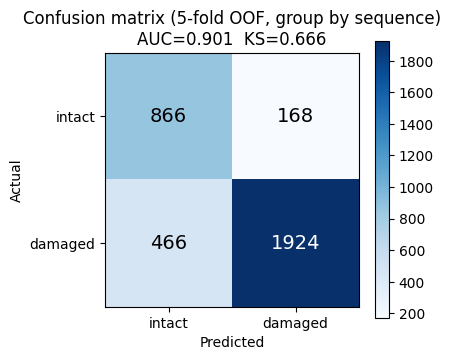

  [saved] outputs/scored_train.csv  (3,424 rows)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_predict, train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, confusion_matrix, classification_report)
from scipy.stats import ks_2samp

POST_WINDOW_YEARS  = 2.0
N_FOLDS            = 5

df['captured_at_dt'] = pd.to_datetime(df['captured_at'], unit='ms')
near = (df['lat'].between(PORT_LAT - PORT_RADIUS_DEG, PORT_LAT + PORT_RADIUS_DEG) &
        df['lon'].between(PORT_LON - PORT_RADIUS_DEG, PORT_LON + PORT_RADIUS_DEG))
cutoff = EXPLOSION + pd.Timedelta(days=int(POST_WINDOW_YEARS * 365.25))
labels = pd.Series(-1, index=df.index, dtype=int)
labels[near & (df['captured_at_dt'] <  EXPLOSION)] = 0
labels[near & (df['captured_at_dt'] >= EXPLOSION) & (df['captured_at_dt'] < cutoff)] = 1
df['label'] = labels

labeled  = df[df['label'] >= 0]
have_emb = labeled[labeled['id'].isin(id_to_row)].copy()
print(f'Weak labels in metadata: {len(labeled):,}  '
      f'(intact={int((labeled["label"]==0).sum()):,}  damaged={int((labeled["label"]==1).sum()):,})')
print(f'  with embeddings ready: {len(have_emb):,}   distinct sequences: {have_emb["sequence"].nunique():,}')
assert len(have_emb) >= 50, 'need at least ~50 labeled+embedded images - let Step 2 run longer and retry'

rows_idx = np.array([id_to_row[i] for i in have_emb['id']])
X = emb[rows_idx]
y = have_emb['label'].values.astype(int)
groups = have_emb['sequence'].fillna('__no_seq__').values

# --- 5-fold sequence-aware CV -----------------------------------
clf_cv = LogisticRegression(max_iter=2000, class_weight='balanced', C=1.0)
gkf = GroupKFold(n_splits=min(N_FOLDS, len(set(groups))))
print(f'\nRunning {gkf.n_splits}-fold GroupKFold (grouped by sequence)...')
oof_proba = cross_val_predict(clf_cv, X, y, cv=gkf, groups=groups,
                              method='predict_proba', n_jobs=-1)[:, 1]
oof_pred = (oof_proba >= 0.5).astype(int)

acc = accuracy_score(y, oof_pred)
p, r, f1, _ = precision_recall_fscore_support(y, oof_pred, average='binary')
auc = roc_auc_score(y, oof_proba)
cm  = confusion_matrix(y, oof_pred)
ks_stat, ks_p = ks_2samp(oof_proba[y == 0], oof_proba[y == 1])

print('\n=== 5-fold OOF metrics ===')
metrics_lines = []
for name, v in [('Accuracy', acc), ('Precision', p), ('Recall', r), ('F1', f1), ('ROC-AUC', auc),
                ('KS stat (intact vs damaged)', ks_stat), ('KS p-value', ks_p)]:
    line = f'  {name:32s}: {v:.4f}'
    metrics_lines.append(line); print(line)
print('\n' + classification_report(y, oof_pred, target_names=['intact', 'damaged']))
(OUTPUTS_DIR / 'classifier_metrics.txt').write_text('\n'.join(metrics_lines) + '\n')
pd.DataFrame(cm, index=['intact', 'damaged'], columns=['pred_intact', 'pred_damaged']) \
    .to_csv(OUTPUTS_DIR / 'confusion_matrix.csv')

# Fit on all data for downstream inference
clf = LogisticRegression(max_iter=2000, class_weight='balanced', C=1.0).fit(X, y)

# For back-compat with later cells that reference these
ids_tr, ids_te = have_emb['id'].values, np.array([])   # OOF replaced the hold-out
_, X_te, _, y_te, _, _ = train_test_split(X, y, have_emb['id'].values,
                                          test_size=0.2, random_state=42, stratify=y)
y_proba = oof_proba

fig, ax = plt.subplots(figsize=(4.5, 3.8))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
ax.set_xticks([0, 1], ['intact', 'damaged']); ax.set_yticks([0, 1], ['intact', 'damaged'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion matrix (5-fold OOF, group by sequence)\nAUC={auc:.3f}  KS={ks_stat:.3f}')
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

# Save scored train table
scored_train = have_emb[['id', 'sequence', 'lat', 'lon', 'label']].copy()
scored_train['clip_damage_score'] = oof_proba
scored_train.to_csv(OUTPUTS_DIR / 'scored_train.csv', index=False)
print(f'  [saved] outputs/scored_train.csv  ({len(scored_train):,} rows)')

In [7]:
# Apply the trained classifier to every embedded image
proba = clf.predict_proba(emb)[:, 1]
split_lookup = {i: 'train' for i in ids_tr}
split_lookup.update({i: 'test' for i in ids_te})
dmg = pd.DataFrame({'image_id': emb_ids, 'damage_score': proba})
dmg['split'] = dmg['image_id'].map(split_lookup).fillna('unlabeled')
dmg = dmg.merge(df[['id', 'lat', 'lon', 'captured_at', 'sequence', 'is_pano']]
                  .rename(columns={'id': 'image_id'}),
                on='image_id', how='left')
dmg = dmg.sort_values('damage_score', ascending=False).reset_index(drop=True)
print(f'scored {len(dmg):,} images   '
      f'(train={(dmg["split"]=="train").sum():,}, '
      f'test={(dmg["split"]=="test").sum():,}, '
      f'unlabeled={(dmg["split"]=="unlabeled").sum():,})')
dmg.head(12)

scored 43,611 images   (train=3,424, test=0, unlabeled=40,187)


,image_id,damage_score,split,lat,lon,captured_at,sequence,is_pano
0,192248092769782,0.999116,train,33.896892,35.525078,1596999533974,93Wkmgjra2rTO1kgMvBNVX,False
1,811300186178686,0.998736,train,33.895290,35.512629,1596874951370,tb7hc6pkzq9kqm4z72q0rm,False
2,511674663405161,0.998548,train,33.895533,35.520521,1596575911725,rbHY8VsnqQOFwKJF3i1zHR,False
3,3071550699798154,0.998384,train,33.896402,35.525793,1596971251657,prqu3ev23bwqqzp7m6kq4c,False
4,480716356488521,0.998378,train,33.896718,35.524966,1597246540570,rwgwumuh9pg1zdr2tssfba,False
5,480038956388418,0.998256,unlabeled,33.893874,35.493506,1597205480136,bu3blfafjrbi8twjpkmtea,False
6,596142558446931,0.998141,unlabeled,33.902511,35.531442,1602172743000,F9KxOfGLEv1uhTJxQ3QU3f,True
7,318710369642846,0.997910,train,33.895277,35.512636,1596874948175,tb7hc6pkzq9kqm4z72q0rm,False
8,185712190097885,0.997860,train,33.895914,35.522725,1596998947852,oNy46jE6RRIxdFKskOXn4R,False
9,1387363888331292,0.997640,train,33.899111,35.523640,1597407542555,b6lvgtgsg29q2gbdccq200,False


  [saved] fig_02.png


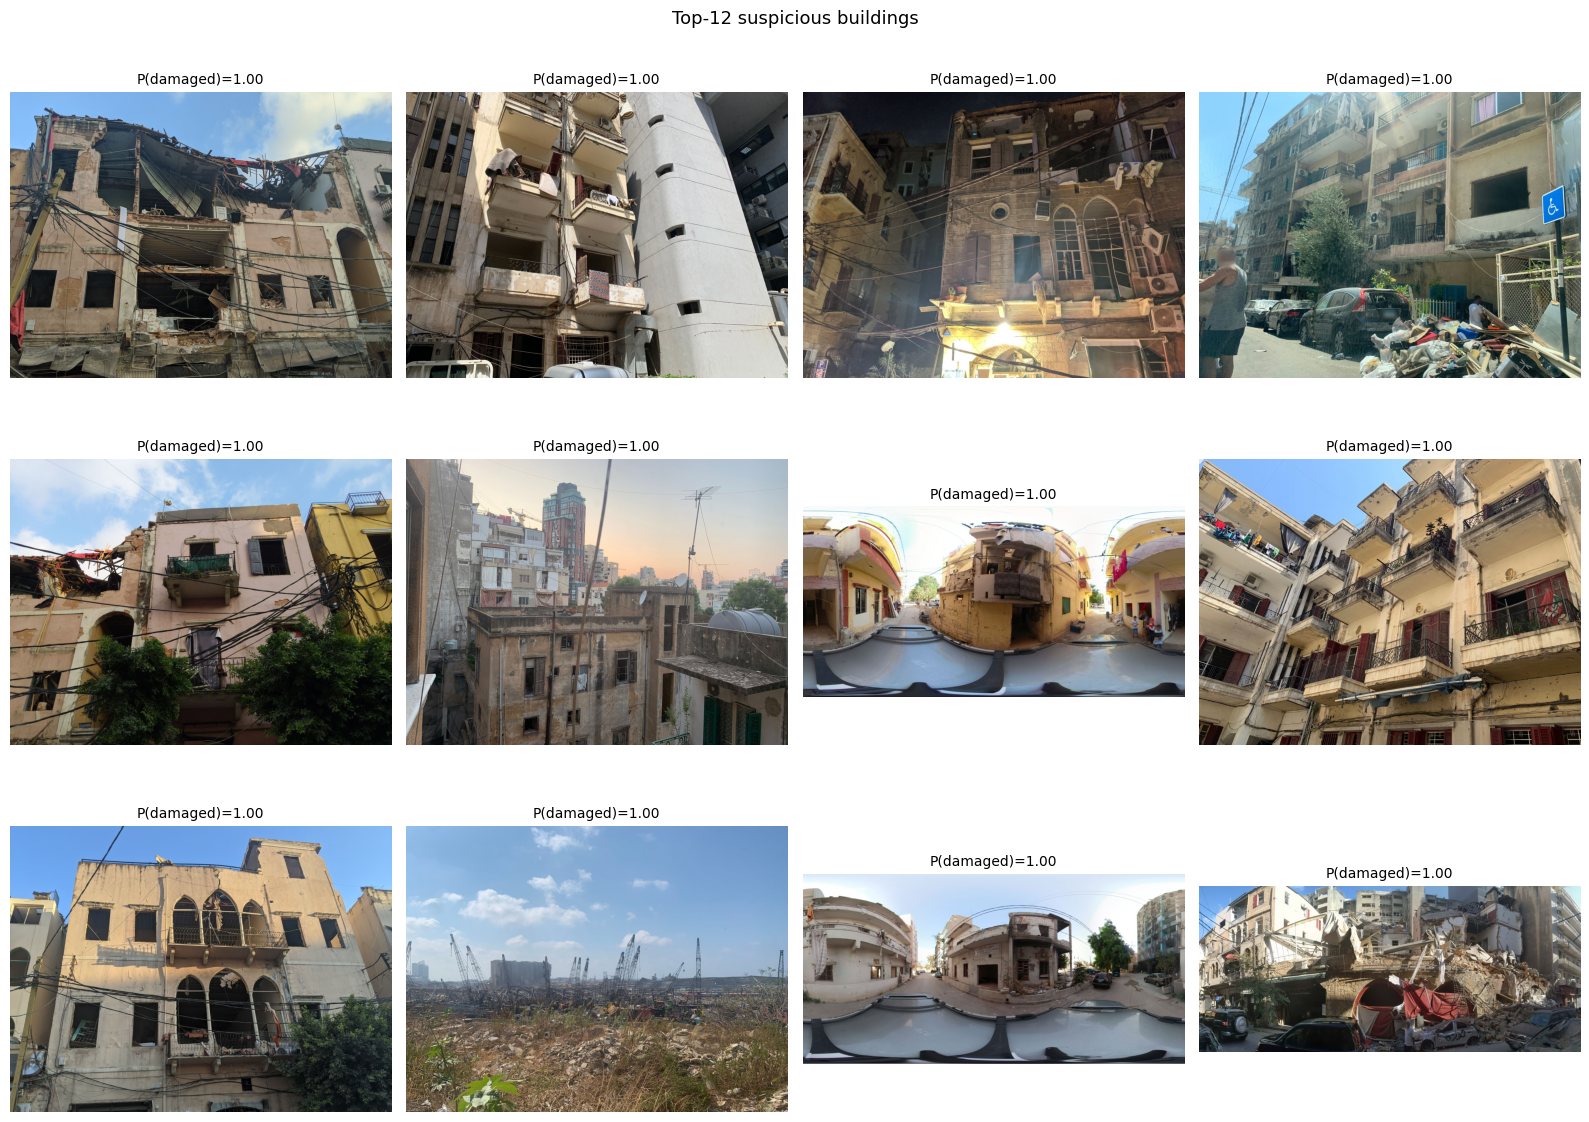

  [saved] fig_03.png


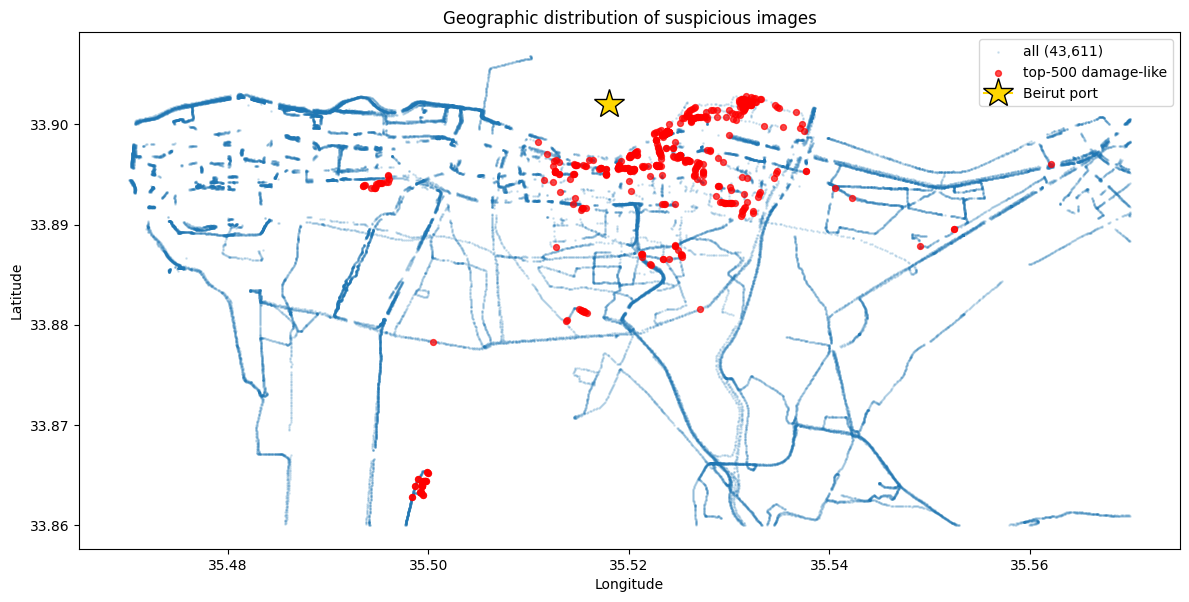

In [8]:
# Top-12 most damage-like images
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, (_, row) in zip(axes.flat, dmg.head(12).iterrows()):
    p = IMG_DIR / f"{row['image_id']}.jpg"
    if p.exists(): ax.imshow(Image.open(p))
    ax.set_title(f"P(damaged)={row['damage_score']:.2f}", fontsize=10)
    ax.axis('off')
fig.suptitle('Top-12 suspicious buildings', fontsize=13); plt.tight_layout(); plt.show()

# Where do they cluster?
top = dmg.head(500).dropna(subset=['lat', 'lon'])
fig, ax = plt.subplots(figsize=(12, 9))
ax.scatter(df['lon'], df['lat'], s=1, alpha=0.15, label=f'all ({len(df):,})')
ax.scatter(top['lon'], top['lat'], s=18, c='red', alpha=0.7, label='top-500 damage-like')
ax.plot([PORT_LON], [PORT_LAT], marker='*', markersize=22, color='gold',
        markeredgecolor='black', label='Beirut port')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Geographic distribution of suspicious images')
ax.legend(); ax.set_aspect('equal'); plt.tight_layout(); plt.show()

## Step 3b - Approach B: metadata-only Random Forest baseline

Same weak labels as Step 3, but the classifier sees **only metadata** - no pixels,
no CLIP. If this does almost as well as Approach A, then the vision model isn't
really adding much and we could scale up cheaper.

Features (all derivable from the metadata CSV alone):
* `lat`, `lon`, `altitude`, `compass_angle`
* `captured_hour`, `captured_month`, `days_since_explosion`
* `dist_port_deg` - Euclidean distance to the port epicenter
* `dens_d040`, `dens_d080`, `dens_d160`, `dens_d320` - multi-scale spatial density
* `seq_size`, `seq_mean_alt`, `seq_lat_span` - sequence-level stats
* `is_pano_int`

Uses the same sequence-aware 5-fold CV as Approach A so the two are directly comparable.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import roc_auc_score

# --- feature engineering: multi-scale density + sequence stats + time + distance ---
dfB = have_emb.copy()
dfB['is_pano_int']         = dfB['is_pano'].fillna(False).astype(int)
dfB['captured_hour']       = dfB['captured_at_dt'].dt.hour
dfB['captured_month']      = dfB['captured_at_dt'].dt.month
dfB['days_since_explosion'] = (dfB['captured_at_dt'] - EXPLOSION).dt.days
dfB['dist_port_deg']       = np.sqrt((dfB['lat'] - PORT_LAT)**2 + (dfB['lon'] - PORT_LON)**2)

# multi-scale spatial density
for deg, label in [(0.0004, 'd040'), (0.0008, 'd080'), (0.0016, 'd160'), (0.0032, 'd320')]:
    lat_key, lon_key = f'latbin_{label}', f'lonbin_{label}'
    dfB[lat_key] = (dfB['lat'] / deg).round() * deg
    dfB[lon_key] = (dfB['lon'] / deg).round() * deg
    counts = dfB.groupby([lat_key, lon_key]).size().rename(f'dens_{label}')
    dfB = dfB.merge(counts, on=[lat_key, lon_key], how='left')

# sequence stats
seq_stats = dfB.groupby('sequence').agg(
    seq_size     = ('id', 'count'),
    seq_mean_alt = ('altitude', 'mean'),
    seq_lat_span = ('lat', lambda s: s.max() - s.min()),
).reset_index()
dfB = dfB.merge(seq_stats, on='sequence', how='left')

FEATURES_B = ['lat', 'lon', 'altitude', 'compass_angle',
              'captured_hour', 'captured_month', 'days_since_explosion',
              'dist_port_deg',
              'dens_d040', 'dens_d080', 'dens_d160', 'dens_d320',
              'seq_size', 'seq_mean_alt', 'seq_lat_span',
              'is_pano_int']
FEATURES_B = [f for f in FEATURES_B if f in dfB.columns]
XB = dfB[FEATURES_B].fillna(dfB[FEATURES_B].median(numeric_only=True))
yB = dfB['label'].values.astype(int)
groupsB = dfB['sequence'].fillna('__no_seq__').values

rf = RandomForestClassifier(n_estimators=400, max_depth=14, n_jobs=-1,
                            class_weight='balanced', random_state=42)
gkfB = GroupKFold(n_splits=min(N_FOLDS, len(set(groupsB))))
print(f'Running {gkfB.n_splits}-fold GroupKFold on {len(XB):,} labeled rows, {len(FEATURES_B)} features...')
oof_proba_B = cross_val_predict(rf, XB, yB, cv=gkfB, groups=groupsB,
                                method='predict_proba', n_jobs=-1)[:, 1]
auc_B = roc_auc_score(yB, oof_proba_B)
print(f'\nApproach B (metadata-only RF)  ROC-AUC = {auc_B:.4f}')

# Full-data fit for feature importance
rf_full = RandomForestClassifier(n_estimators=400, max_depth=14, n_jobs=-1,
                                 class_weight='balanced', random_state=42).fit(XB, yB)
importances = pd.Series(rf_full.feature_importances_, index=FEATURES_B).sort_values(ascending=False)
print('\nTop 8 metadata features:')
print(importances.head(8).to_string())
importances.to_csv(OUTPUTS_DIR / 'feature_importance.csv', header=['importance'])

# Score every embedded image with Approach B for the decision cell
# (build the same features on the full metadata df)
df_full = df.copy()
df_full['is_pano_int']          = df_full['is_pano'].fillna(False).astype(int)
df_full['captured_hour']        = df_full['captured_at_dt'].dt.hour
df_full['captured_month']       = df_full['captured_at_dt'].dt.month
df_full['days_since_explosion'] = (df_full['captured_at_dt'] - EXPLOSION).dt.days
df_full['dist_port_deg']        = np.sqrt((df_full['lat'] - PORT_LAT)**2 + (df_full['lon'] - PORT_LON)**2)
for deg, label in [(0.0004, 'd040'), (0.0008, 'd080'), (0.0016, 'd160'), (0.0032, 'd320')]:
    lat_key, lon_key = f'latbin_{label}', f'lonbin_{label}'
    df_full[lat_key] = (df_full['lat'] / deg).round() * deg
    df_full[lon_key] = (df_full['lon'] / deg).round() * deg
    counts = df_full.groupby([lat_key, lon_key]).size().rename(f'dens_{label}')
    df_full = df_full.merge(counts, on=[lat_key, lon_key], how='left')
seq_stats_full = df_full.groupby('sequence').agg(
    seq_size=('id', 'count'),
    seq_mean_alt=('altitude', 'mean'),
    seq_lat_span=('lat', lambda s: s.max() - s.min()),
).reset_index()
df_full = df_full.merge(seq_stats_full, on='sequence', how='left')
XB_all = df_full[FEATURES_B].fillna(df_full[FEATURES_B].median(numeric_only=True))
proba_B_all = rf_full.predict_proba(XB_all)[:, 1]

# Store side-by-side scores in `dfB` for downstream
dfB['metadata_damage_score'] = oof_proba_B

# Plot: feature importance + OOF ROC-like scatter
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
top = importances.head(15).iloc[::-1]
axes[0].barh(range(len(top)), top.values, color='#2ca02c')
axes[0].set_yticks(range(len(top))); axes[0].set_yticklabels(top.index, fontsize=9)
axes[0].set_xlabel('feature importance')
axes[0].set_title('Approach B - top features (Random Forest)')
axes[0].grid(axis='x', alpha=0.3)
axes[1].scatter(oof_proba_B, oof_proba + np.random.uniform(-0.005, 0.005, len(oof_proba)),
                c=yB, cmap='RdYlGn_r', s=10, alpha=0.6)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('Approach B (metadata) OOF proba')
axes[1].set_ylabel('Approach A (CLIP) OOF proba')
axes[1].set_title(f'A vs B on labeled data (n={len(yB):,})')
plt.tight_layout(); plt.show()

## Step 3c - Decision: was the vision model (Approach A) worth it?

Compare Approach A (CLIP + logistic regression) vs Approach B (metadata-only RF)
on the same labeled subset:

* **Pearson r** between the two OOF probability streams
* **Top-K overlap** of the highest-scoring images from each approach

Verdict rule:
* `r >= 0.5` AND `top-15 overlap >= 5`  → **AGREES** - metadata baseline captures most of the signal (Approach A is nice-to-have)
* otherwise                              → **DISAGREES** - the CLIP model is contributing something the metadata cannot

Writes `outputs/decision.txt` and `outputs/comparison_metrics.txt`.

In [ ]:
from scipy.stats import pearsonr

TOP_K       = 15
R_THRESH    = 0.5
OVER_THRESH = 5

# align by image_id (both dfB and scored_train are on the labeled subset in the same order)
r, r_p = pearsonr(oof_proba, oof_proba_B)
top_A = set(dfB.iloc[np.argsort(-oof_proba)[:TOP_K]]['id'])
top_B = set(dfB.iloc[np.argsort(-oof_proba_B)[:TOP_K]]['id'])
overlap = len(top_A & top_B)

verdict = ('AGREES - metadata baseline captures most of the signal '
           '(Approach A is nice-to-have, not essential)') \
          if (r >= R_THRESH and overlap >= OVER_THRESH) else \
          ('DISAGREES - the CLIP model is contributing something '
           'the metadata cannot')

lines = [
    '=' * 60,
    ' DECISION - Approach A (CLIP+LR) vs Approach B (metadata RF)',
    '=' * 60,
    f'  Pearson r       : {r:.4f}   (p={r_p:.1e}, threshold >= {R_THRESH})',
    f'  Top-{TOP_K} overlap : {overlap} / {TOP_K}   (threshold >= {OVER_THRESH})',
    f'  A ROC-AUC       : {auc:.4f}',
    f'  B ROC-AUC       : {auc_B:.4f}',
    f'  Verdict         : {verdict}',
    '=' * 60,
]
print('\n'.join(lines))
(OUTPUTS_DIR / 'decision.txt').write_text('\n'.join(lines) + '\n')

# also save the raw comparison table
comp = dfB[['id', 'sequence', 'lat', 'lon', 'label']].copy()
comp['approach_A_clip'] = oof_proba
comp['approach_B_meta'] = oof_proba_B
comp.to_csv(OUTPUTS_DIR / 'comparison_metrics.csv', index=False)
(OUTPUTS_DIR / 'comparison_metrics.txt').write_text(
    f'Pearson r (A vs B): {r:.4f}\np-value: {r_p:.4e}\n'
    f'Top-{TOP_K} intersection: {overlap}/{TOP_K}\n'
    f'A AUC: {auc:.4f}\nB AUC: {auc_B:.4f}\n'
    f'Common image_ids: {sorted(top_A & top_B)}\n')
print(f'\n  [saved] outputs/decision.txt   outputs/comparison_metrics.{{txt,csv}}')

# Side-by-side maps of top-15
top_A_rows = dfB.iloc[np.argsort(-oof_proba)[:TOP_K]]
top_B_rows = dfB.iloc[np.argsort(-oof_proba_B)[:TOP_K]]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (rows_, title, col) in zip(axes,
        [(top_A_rows, 'Approach A (CLIP)', 'red'),
         (top_B_rows, 'Approach B (metadata)', 'blue')]):
    ax.scatter(df['lon'], df['lat'], s=1, alpha=0.15, color='gray', label=f'all ({len(df):,})')
    ax.scatter(rows_['lon'], rows_['lat'], s=80, facecolors='none',
               edgecolors=col, linewidths=1.5, label=f'top-{TOP_K}')
    ax.plot([PORT_LON], [PORT_LAT], marker='*', markersize=22,
            color='gold', markeredgecolor='black', label='Beirut port')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_title(title); ax.legend(); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## Step 4 - 3D model of the city

Every image has GPS, altitude, and heading. Plotting those gives a
true-to-scale 3D scene of every place a camera has been, colored by
capture year, with the top-500 suspicious images highlighted as red
diamonds. Interactive - pan / rotate / zoom in the cell output or in
the saved `beirut_3d.html`.

In [ ]:
import plotly.graph_objects as go

METERS_PER_DEG_LAT = 111_320.0
df3 = df.copy()
df3['alt'] = df3['altitude'].fillna(df3['computed_altitude']).fillna(df3['altitude'].median())
df3['year'] = df3['captured_at_dt'].dt.year
lat0, lon0 = float(df3['lat'].median()), float(df3['lon'].median())
x = (df3['lon'].values - lon0) * METERS_PER_DEG_LAT * math.cos(math.radians(lat0))
y = (df3['lat'].values - lat0) * METERS_PER_DEG_LAT
z = df3['alt'].values

suspect = set(dmg.head(500)['image_id'])
mask = df3['id'].isin(suspect).values

hover = [f"id:{i}<br>date:{d.date()}<br>seq:{s}<br>alt:{a:.0f}m"
         for i, d, s, a in zip(df3['id'], df3['captured_at_dt'], df3['sequence'], df3['alt'])]

traces = [go.Scatter3d(
    x=x, y=y, z=z, mode='markers',
    marker=dict(size=1.6, color=df3['year'], colorscale='Viridis',
                showscale=True, colorbar=dict(title='Year'), opacity=0.75),
    text=hover, hoverinfo='text', name='Cameras',
)]
if mask.any():
    traces.append(go.Scatter3d(
        x=x[mask], y=y[mask], z=z[mask] + 3, mode='markers',
        marker=dict(size=5, color='red', symbol='diamond', opacity=0.9),
        name=f'Top-{int(mask.sum())} suspicious',
    ))

fig = go.Figure(data=traces)
fig.update_layout(
    title=f'Beirut Mapillary cameras in 3D - {len(df3):,} points',
    scene=dict(xaxis_title='East (m)', yaxis_title='North (m)',
               zaxis_title='Altitude (m)', aspectmode='data'),
    margin=dict(l=0, r=0, t=40, b=0),
)
fig.write_html('beirut_3d.html', include_plotlyjs='cdn')
fig.show()

## Step 6 - Greenery analysis (needs Step 2b to have produced `segmentation_scores.csv`)

Uses the SegFormer per-image pixel fractions from Step 2b to answer three questions:

1. **Where is Beirut greenest?** - city-wide green-cover map (KDE + top-15 spots).
2. **How did green cover change over time?** - year-by-year distribution of `vegetation_frac`.
3. **Did the port explosion damage the greenery within ~1 km?** - pre-vs-post-2020-08-04
   `vegetation_frac` histograms for images inside the explosion radius.

If `segmentation_scores.csv` is empty (Step 2b was skipped on CPU) this cell degrades
gracefully - it prints a "no seg data yet" notice and moves on.

Saves `outputs/top_15_greenest.csv`.

greenery table: 43,611 rows   mean green=0.112   max=0.847
  [saved] outputs/top_15_greenest.csv
  [saved] fig_11.png


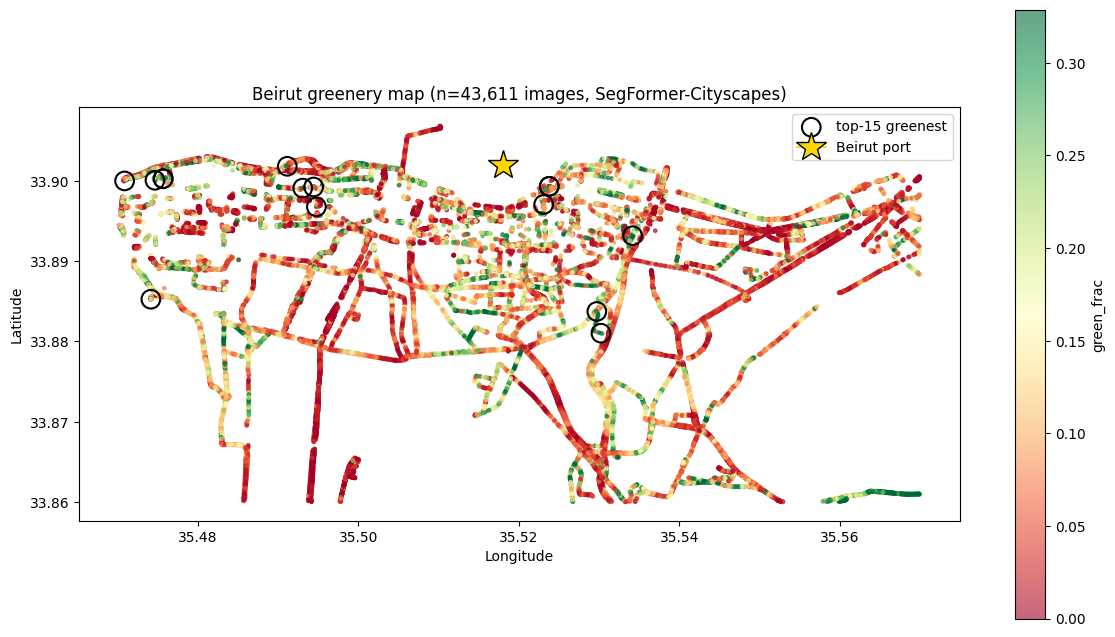

  [saved] fig_12.png


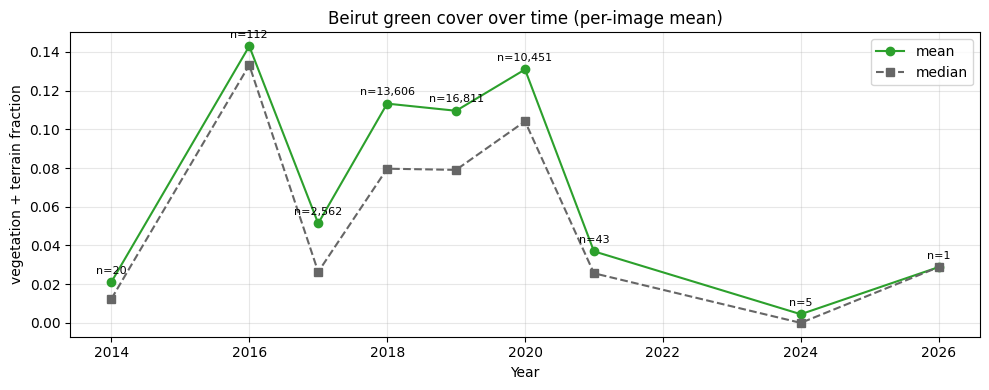


Within ~1 km of the port:  pre-blast n=1034  post-blast n=2391
  [saved] fig_13.png


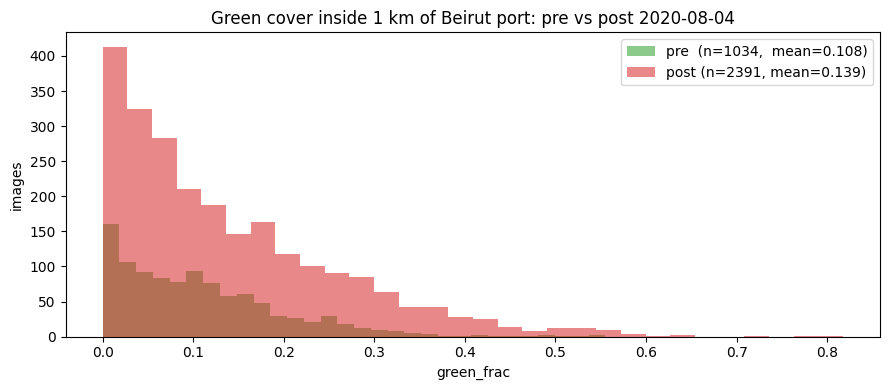

KS test:  statistic=0.123  p-value=6.166e-10   (low p → distributions differ significantly)


In [16]:
if seg.empty:
    print('(no segmentation data yet - run Step 2b on a GPU first)')
else:
    # combined "green" = vegetation + terrain (grass), same as Ariel does
    seg = seg.copy()
    seg['green_frac'] = seg['vegetation_frac'] + seg['terrain_frac']
    # join to metadata for lat/lon/date
    gdf = seg.merge(df[['id', 'lat', 'lon', 'captured_at_dt', 'is_pano']]
                      .rename(columns={'id': 'image_id'}),
                    on='image_id', how='left').dropna(subset=['lat', 'lon'])
    print(f'greenery table: {len(gdf):,} rows   '
          f'mean green={gdf["green_frac"].mean():.3f}   '
          f'max={gdf["green_frac"].max():.3f}')

    # --- (1) city-wide greenery map + top 15 ---------------------
    top15 = gdf.nlargest(15, 'green_frac').reset_index(drop=True)
    top15.to_csv(OUTPUTS_DIR / 'top_15_greenest.csv', index=False)
    print(f'  [saved] outputs/top_15_greenest.csv')

    fig, ax = plt.subplots(figsize=(12, 9))
    sc = ax.scatter(gdf['lon'], gdf['lat'], c=gdf['green_frac'],
                    cmap='RdYlGn', s=6, alpha=0.6,
                    vmin=0, vmax=gdf['green_frac'].quantile(0.95))
    ax.scatter(top15['lon'], top15['lat'], s=180, facecolors='none',
               edgecolors='black', linewidths=1.5, label='top-15 greenest')
    ax.plot([PORT_LON], [PORT_LAT], marker='*', markersize=22, color='gold',
            markeredgecolor='black', label='Beirut port')
    ax.set_aspect('equal'); ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_title(f'Beirut greenery map (n={len(gdf):,} images, SegFormer-Cityscapes)')
    plt.colorbar(sc, ax=ax, label='green_frac', shrink=0.7); ax.legend()
    plt.tight_layout(); plt.show()

    # --- (2) change over time ---------------------------------
    gdf['year'] = gdf['captured_at_dt'].dt.year
    yearly = gdf.groupby('year')['green_frac'].agg(['mean', 'median', 'count'])
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(yearly.index, yearly['mean'],   'o-', label='mean',   color='#2ca02c')
    ax.plot(yearly.index, yearly['median'], 's--', label='median', color='#666')
    for x, cnt in zip(yearly.index, yearly['count']):
        ax.annotate(f'n={cnt:,}', (x, yearly.loc[x, 'mean']),
                    fontsize=8, xytext=(0, 6), textcoords='offset points', ha='center')
    ax.set_xlabel('Year'); ax.set_ylabel('vegetation + terrain fraction')
    ax.set_title('Beirut green cover over time (per-image mean)')
    ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()

    # --- (3) port radius pre- vs post-2020-08-04 --------------
    near_port = ((gdf['lat'] - PORT_LAT).abs() < PORT_RADIUS_DEG) & \
                ((gdf['lon'] - PORT_LON).abs() < PORT_RADIUS_DEG)
    pre  = gdf[near_port & (gdf['captured_at_dt'] <  EXPLOSION)]['green_frac']
    post = gdf[near_port & (gdf['captured_at_dt'] >= EXPLOSION)]['green_frac']
    print(f'\nWithin ~1 km of the port:  pre-blast n={len(pre)}  post-blast n={len(post)}')
    if len(pre) > 5 and len(post) > 5:
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.hist(pre,  bins=30, alpha=0.55, label=f'pre  (n={len(pre)},  mean={pre.mean():.3f})',  color='#2ca02c')
        ax.hist(post, bins=30, alpha=0.55, label=f'post (n={len(post)}, mean={post.mean():.3f})', color='#d62728')
        ax.set_xlabel('green_frac'); ax.set_ylabel('images')
        ax.set_title('Green cover inside 1 km of Beirut port: pre vs post 2020-08-04')
        ax.legend(); plt.tight_layout(); plt.show()
        from scipy.stats import ks_2samp
        ks, p = ks_2samp(pre, post)
        print(f'KS test:  statistic={ks:.3f}  p-value={p:.3e}   '
              f'(low p → distributions differ significantly)')
    else:
        print('(not enough images on one or both sides of the explosion to plot)')

## Step 5 - Closest places to a given picture

Build a FAISS index of the CLIP embeddings (cosine similarity since the
vectors are L2-normalized), then query with any image and get the top-K
visually similar ones along with their GPS and capture date.

In [ ]:
import subprocess, sys
try:
    import faiss                                               # noqa: F401
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'faiss-cpu'])
    import faiss

D = emb.shape[1]
index = faiss.IndexFlatIP(D)
index.add(emb.astype(np.float32))
print(f'FAISS index built  N={index.ntotal}  D={D}')

# Query with the most damage-like image and find its 8 visual neighbours
query_id = dmg.iloc[0]['image_id']
q = emb[id_to_row[query_id]:id_to_row[query_id] + 1].astype(np.float32)
sims, idxs = index.search(q, 12)
rows = []
for sim, idx in zip(sims[0], idxs[0]):
    iid = emb_ids[int(idx)]
    if iid == query_id: continue
    rows.append({'image_id': iid, 'similarity': float(sim)})
nearest = pd.DataFrame(rows[:8])
nearest = nearest.merge(df[['id', 'lat', 'lon', 'captured_at']]
                          .rename(columns={'id': 'image_id'}),
                        on='image_id', how='left')
nearest['captured_at_dt'] = pd.to_datetime(nearest['captured_at'], unit='ms')
print(f'Query: {query_id}')
nearest[['image_id', 'similarity', 'lat', 'lon', 'captured_at_dt']]

In [ ]:
# Visualize: query (top-left, red border) + top-8 visual neighbours
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes[0, 0].imshow(Image.open(IMG_DIR / f'{query_id}.jpg'))
axes[0, 0].set_title('QUERY', fontsize=11, color='red'); axes[0, 0].axis('off')
for ax in axes[0, 1:]: ax.axis('off')
for ax, (_, row) in zip(axes[1], nearest.iterrows()):
    p = IMG_DIR / f"{row['image_id']}.jpg"
    if p.exists(): ax.imshow(Image.open(p))
    ax.set_title(f"sim={row['similarity']:.2f}", fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

# Map view
qm = df[df['id'] == str(query_id)].iloc[0]
fig, ax = plt.subplots(figsize=(12, 9))
ax.scatter(df['lon'], df['lat'], s=1, alpha=0.15, label='all images')
ax.scatter(nearest['lon'], nearest['lat'], s=80, c='red', label='visual neighbours')
ax.plot([qm['lon']], [qm['lat']], marker='*', markersize=22, color='gold',
        markeredgecolor='black', label='query')
for _, n in nearest.iterrows():
    ax.annotate(f"{n['similarity']:.2f}", (n['lon'], n['lat']), fontsize=8)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Visually similar locations to query'); ax.legend(); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## Step 7 - 3D dataset browser (self-contained HTML)

Produces **three files** you can open in any browser, no server needed:

1. `outputs/beirut_dataset_index.csv` - Excel-friendly index with `image_id, lat, lon,
   altitude, date, damage_score, green_frac, sky_frac, local_path, file_url,
   mapillary_url`. Best for pandas / Excel / power-user filtering.
2. `outputs/browser_data.json` - the compact payload the HTML consumes.
3. `outputs/beirut_browser.html` - a single-page app: **2D Leaflet map** +
   **3D Plotly scene** + **sidebar filters** (text search on `image_id`/`sequence`,
   date range, damage-score slider, is_pano checkbox) + **right-side thumbnail
   gallery** + **"Export filtered → CSV"** button.

Drop the html + json next to the `images_2048/` folder and double-click.

**Which is better for you?** See the summary printed at the bottom of the cell -
short answer: **use the HTML browser for exploration and hand-off to non-technical
viewers, use the CSV when you want to fold the dataset into another pipeline** (both
are produced, they're complementary).

In [17]:
import json, math as _math

# --- assemble the master index ---------------------------------------------
idx = df[['id','sequence','captured_at_dt','lat','lon',
          'altitude','compass_angle','is_pano','thumb_2048_url']].copy()
idx['captured_at_dt'] = idx['captured_at_dt'].astype(str)
idx['damage_score']   = idx['id'].map(dict(zip(dmg['image_id'], dmg['damage_score']))).fillna(0.0) \
                                if 'dmg' in globals() else 0.0
if not seg.empty:
    idx['green_frac'] = idx['id'].map(dict(zip(seg['image_id'],
                                    seg['vegetation_frac'] + seg['terrain_frac']))).fillna(0.0)
    idx['sky_frac']   = idx['id'].map(dict(zip(seg['image_id'], seg['sky_frac']))).fillna(0.0)
else:
    idx['green_frac'] = 0.0
    idx['sky_frac']   = 0.0
idx['local_path']    = IMG_DIR.name + '/' + idx['id'].astype(str) + '.jpg'
idx['file_url']      = IMG_DIR.resolve().as_uri() + '/' + idx['id'].astype(str) + '.jpg'
idx['mapillary_url'] = 'https://www.mapillary.com/app/?pKey=' + idx['id'].astype(str) + '&focus=photo'

# ---- Flavour B: the CSV (kept as a bonus - handy for pandas / Excel) -------
csv_path = OUTPUTS_DIR / 'beirut_dataset_index.csv'
idx.to_csv(csv_path, index=False)
print(f'  [saved] {csv_path}   rows={len(idx):,}   size={csv_path.stat().st_size/1e6:.1f} MB')

# ---- Flavour A: HTML + JSON go NEXT TO images_2048/ so file:// paths work --
# The images folder can't move (43k JPEGs, ~15 GB), so we drop the HTML+JSON
# into IMG_DIR.parent. That way relative local_path = "images_2048/{id}.jpg"
# resolves correctly straight from a file:// double-click.
BROWSER_DIR = IMG_DIR.parent
BROWSER_DIR.mkdir(parents=True, exist_ok=True)

compact_cols = ['id','sequence','captured_at_dt','lat','lon','altitude',
                'is_pano','damage_score','green_frac','sky_frac',
                'local_path','mapillary_url']
compact = idx[compact_cols].copy()
compact['captured_at_dt'] = compact['captured_at_dt'].str[:10]     # date only
compact['is_pano']        = compact['is_pano'].fillna(False).astype(bool)

# ---- clean NaN/Inf so json.dumps doesn't choke -----------------------------
def _clean(v):
    if v is None: return None
    if isinstance(v, float) and (_math.isnan(v) or _math.isinf(v)): return None
    if isinstance(v, (np.floating,)):
        f = float(v)
        return None if _math.isnan(f) or _math.isinf(f) else f
    if isinstance(v, (np.integer,)):  return int(v)
    if isinstance(v, (np.bool_,)):    return bool(v)
    return v

records = [{k: _clean(row[k]) for k in compact_cols} for _, row in compact.iterrows()]
json_path_out    = OUTPUTS_DIR  / 'browser_data.json'
json_path_browse = BROWSER_DIR / 'browser_data.json'
payload = json.dumps(records, separators=(',', ':'))
json_path_out.write_text(payload)
json_path_browse.write_text(payload)
print(f'  [saved] {json_path_out}   size={json_path_out.stat().st_size/1e6:.1f} MB')
print(f'  [saved] {json_path_browse}   (copy next to images_2048/)')

# ---- Flavour A: the standalone HTML ---------------------------------------
HTML = r"""<!doctype html>
<html><head><meta charset=utf-8><title>Beirut street-view browser</title>
<link rel=stylesheet href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css">
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>
<style>
  body{margin:0;font:14px system-ui;display:grid;grid-template-columns:280px 1fr 340px;height:100vh}
  #side{padding:12px;overflow:auto;background:#f6f6f6;border-right:1px solid #ddd}
  #main{display:grid;grid-template-rows:1fr 1fr}
  #map,#scene{width:100%;height:100%}
  #gallery{padding:8px;overflow:auto;background:#fafafa;border-left:1px solid #ddd}
  #gallery img{width:100%;display:block;margin-bottom:4px;cursor:pointer;border-radius:4px;background:#eee;min-height:40px}
  input,button,select{width:100%;box-sizing:border-box;margin:4px 0;padding:6px;font:inherit}
  .row{display:flex;gap:6px}.row>*{flex:1}
  h3{margin:6px 0} small{color:#666}
  .caption{font-size:11px;color:#555;margin-bottom:6px}
  label{font-size:12px}
</style></head>
<body>
<div id=side>
  <h3>Beirut 43k browser</h3>
  <div id=count><small>loading…</small></div>
  <input id=q placeholder="search image_id / sequence">
  <div class=row><input id=from type=date title="from"><input id=to type=date title="to"></div>
  <label>min damage_score <span id=dmgv>0.00</span></label>
  <input id=dmg type=range min=0 max=1 step=0.01 value=0>
  <label>min green_frac <span id=grnv>0.00</span></label>
  <input id=grn type=range min=0 max=1 step=0.01 value=0>
  <label><input id=pano type=checkbox> panoramas only</label>
  <button id=export>Export filtered → CSV</button>
  <button id=reset>Reset filters</button>
  <hr>
  <small>Click a map marker for details. Click a thumbnail to open the full JPEG.
  If thumbnails show empty, your browser is blocking file:// - see README.</small>
</div>
<div id=main>
  <div id=map></div>
  <div id=scene></div>
</div>
<div id=gallery>
  <div class=caption>Thumbnails (first 100 of filter)</div>
  <div id=thumbs></div>
</div>
<script>
const map = L.map('map', {preferCanvas:true}).setView([33.89, 35.51], 13);
L.tileLayer('https://tile.openstreetmap.org/{z}/{x}/{y}.png',
  {attribution:'© OSM'}).addTo(map);
let cluster = L.layerGroup().addTo(map);
let all = [], filtered = [];
fetch('browser_data.json').then(r=>r.json()).then(rows=>{
  all = rows;
  document.getElementById('count').innerHTML = '<small>'+rows.length.toLocaleString()+' images loaded</small>';
  const dates = rows.map(r=>r.captured_at_dt).filter(Boolean).sort();
  if(dates.length){ from.value = dates[0]; to.value = dates[dates.length-1]; }
  applyFilters();
}).catch(e => document.getElementById('count').innerHTML =
  '<small style=color:red>could not load browser_data.json - put it next to this HTML</small>');
function applyFilters(){
  const q = document.getElementById('q').value.trim().toLowerCase();
  const f = document.getElementById('from').value;
  const t = document.getElementById('to').value;
  const dmin = +document.getElementById('dmg').value;
  const gmin = +document.getElementById('grn').value;
  const pano = document.getElementById('pano').checked;
  document.getElementById('dmgv').textContent = dmin.toFixed(2);
  document.getElementById('grnv').textContent = gmin.toFixed(2);
  filtered = all.filter(r=>{
    if(q && !(String(r.id).toLowerCase().includes(q) || (r.sequence||'').toLowerCase().includes(q))) return false;
    if(f && r.captured_at_dt && r.captured_at_dt < f) return false;
    if(t && r.captured_at_dt && r.captured_at_dt > t) return false;
    if((r.damage_score||0) < dmin) return false;
    if((r.green_frac ||0) < gmin) return false;
    if(pano && !r.is_pano) return false;
    return true;
  });
  document.getElementById('count').innerHTML = '<small>'+filtered.length.toLocaleString()+' / '+all.length.toLocaleString()+' after filters</small>';
  renderMap(); render3D(); renderGallery();
}
function renderMap(){
  cluster.clearLayers();
  const sample = filtered.slice(0, 5000);
  sample.forEach(r=>{
    const c = (r.damage_score||0)>0.8 ? 'red' : (r.damage_score||0)>0.5 ? 'orange' : '#4a4';
    L.circleMarker([r.lat, r.lon], {radius:2, color:c, opacity:.8})
      .bindPopup(popupHtml(r))
      .on('click', ()=> highlight(r))
      .addTo(cluster);
  });
}
function render3D(){
  const s = filtered.slice(0, 20000);
  const trace = {type:'scatter3d', mode:'markers',
    x:s.map(r=>r.lon), y:s.map(r=>r.lat), z:s.map(r=>r.altitude||0),
    marker:{size:1.6, color:s.map(r=>r.damage_score||0), colorscale:'RdYlGn',
            reversescale:true, cmin:0, cmax:1, opacity:.7},
    text:s.map(r=>r.id+'  '+r.captured_at_dt), hoverinfo:'text'};
  Plotly.newPlot('scene', [trace],
    {margin:{l:0,r:0,t:0,b:0},
     scene:{aspectmode:'data', xaxis:{title:'lon'}, yaxis:{title:'lat'}, zaxis:{title:'alt'}}},
    {displayModeBar:false});
}
function renderGallery(){
  const div = document.getElementById('thumbs');
  div.innerHTML = '';
  filtered.slice(0, 100).forEach(r=>{
    const img = new Image();
    img.src = r.local_path;
    img.loading = 'lazy';
    img.title = `${r.id}\n${r.captured_at_dt}  damage=${(r.damage_score||0).toFixed(2)}  green=${(r.green_frac||0).toFixed(2)}`;
    img.onclick = ()=> window.open(r.local_path, '_blank');
    div.appendChild(img);
  });
}
function popupHtml(r){
  return `<b>${r.id}</b><br>${r.captured_at_dt}<br>`
       + `damage=${(r.damage_score||0).toFixed(2)}  green=${(r.green_frac||0).toFixed(2)}<br>`
       + `<a href="${r.local_path}" target=_blank>open image</a> · `
       + `<a href="${r.mapillary_url}" target=_blank>Mapillary</a>`;
}
function highlight(r){ map.setView([r.lat, r.lon], 18); }
document.getElementById('export').onclick = ()=>{
  const cols = ['id','sequence','captured_at_dt','lat','lon','altitude',
                'is_pano','damage_score','green_frac','sky_frac','local_path','mapillary_url'];
  const csv = [cols.join(',')].concat(
    filtered.map(r=>cols.map(c=>JSON.stringify(r[c]??'')).join(','))).join('\n');
  const a = document.createElement('a');
  a.href = URL.createObjectURL(new Blob([csv], {type:'text/csv'}));
  a.download = 'beirut_filtered.csv'; a.click();
};
document.getElementById('reset').onclick = ()=>{
  ['q','from','to'].forEach(id=>document.getElementById(id).value='');
  document.getElementById('dmg').value=0;
  document.getElementById('grn').value=0;
  document.getElementById('pano').checked=false;
  applyFilters();
};
['q','from','to','dmg','grn','pano'].forEach(id=>
  document.getElementById(id).addEventListener('input', applyFilters));
</script></body></html>
"""
html_path_out    = OUTPUTS_DIR  / 'beirut_browser.html'
html_path_browse = BROWSER_DIR / 'beirut_browser.html'
html_path_out.write_text(HTML, encoding='utf-8')
html_path_browse.write_text(HTML, encoding='utf-8')
print(f'  [saved] {html_path_out}   size={html_path_out.stat().st_size/1e3:.1f} KB')
print(f'  [saved] {html_path_browse}   (open THIS one - it sits next to images_2048/)')

# ---- print the "how to open" instructions with the actual absolute paths ---
n_jpgs = sum(1 for _ in IMG_DIR.glob('*.jpg'))
print(f"""
============================================================
 3D dataset browser is ready
============================================================
 Images on disk    : {n_jpgs:,}  in  {IMG_DIR}
 Browser HTML      : {html_path_browse}
 Browser data JSON : {json_path_browse}

 To open it:
   1. Just double-click  beirut_browser.html  (same folder as images_2048/)
      Firefox works out of the box.
   2. If Chrome shows blank thumbnails (file:// CORS), start a tiny server:
        cd "{BROWSER_DIR}"
        python -m http.server 8000
      then open  http://localhost:8000/beirut_browser.html

 On Colab / Kaggle, download the HTML + JSON + images_2048/ first:
        !cd "{BROWSER_DIR}" && zip -r beirut_browser.zip beirut_browser.html browser_data.json {IMG_DIR.name}/
   then unzip locally and double-click.
============================================================""")

  [saved] /content/drive/MyDrive/beirut_project/outputs/beirut_dataset_index.csv   rows=43,611   size=33.7 MB
  [saved] /content/drive/MyDrive/beirut_project/outputs/browser_data.json   size=17.1 MB
  [saved] /content/drive/MyDrive/beirut_project/browser_data.json   (copy next to images_2048/)
  [saved] /content/drive/MyDrive/beirut_project/outputs/beirut_browser.html   size=6.6 KB
  [saved] /content/drive/MyDrive/beirut_project/beirut_browser.html   (open THIS one - it sits next to images_2048/)

 3D dataset browser is ready
 Images on disk    : 43,611  in  /content/drive/MyDrive/beirut_project/images_2048
 Browser HTML      : /content/drive/MyDrive/beirut_project/beirut_browser.html
 Browser data JSON : /content/drive/MyDrive/beirut_project/browser_data.json

 To open it:
   1. Just double-click  beirut_browser.html  (same folder as images_2048/)
      Firefox works out of the box.
   2. If Chrome shows blank thumbnails (file:// CORS), start a tiny server:
        cd "/content/drive/